# MobileNetV3 Large: Disease Classification & Severity Estimation

This notebook trains a MobileNetV3 Large model to classify 9 different apple diseases.
It also implements a heuristic computer vision approach to estimate disease severity (1-5 scale) since severity labels are not available in the dataset.

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
# Configuration
# Updated paths for the 9-class dataset structure
BASE_DIR = r"C:\Users\seeds\Desktop\SeedScan\Apple DataSet_Preprocessed"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
SAVE_DIR = r"C:\Users\seeds\Desktop\SeedScan\saved_model_mobilenetv3_large"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.0001

os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Train Directory: {TRAIN_DIR}")
print(f"Test Directory: {TEST_DIR}")

Train Directory: C:\Users\seeds\Desktop\SeedScan\Apple DataSet_Preprocessed\train
Test Directory: C:\Users\seeds\Desktop\SeedScan\Apple DataSet_Preprocessed\test


In [3]:
# Data Generators
print("\nSetting up data generators...")

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation/Test generator (no augmentation, just preprocessing)
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Important for evaluation
)


Setting up data generators...
Found 78266 images belonging to 9 classes.
Found 19763 images belonging to 9 classes.


In [4]:
# Save Class Indices
class_indices = train_generator.class_indices
num_classes = len(class_indices)
class_indices_path = os.path.join(SAVE_DIR, 'class_indices.json')

with open(class_indices_path, 'w') as f:
    json.dump(class_indices, f)

print(f"Found {num_classes} classes: {list(class_indices.keys())}")

Found 9 classes: ['Altenaria_Leaf_Spot', 'Apple_scab', 'Black_rot', 'Brown spot', 'Cedar_apple_rust', 'Grey spot', 'Healthy', 'Mosaic', 'Powdery_Mildew']


In [5]:
# Build Model
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model initially
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['input_1[0][0]']             
                                                                                                  
 Conv (Conv2D)               (None, 112, 112, 16)         432       ['rescaling[0][0]']           
                                                                                                  
 Conv/BatchNorm (BatchNorma  (None, 112, 112, 16)         64        ['Conv[0][0]']                
 lization)                                                                                  

In [7]:
# Callbacks
checkpoint_path = os.path.join(SAVE_DIR, "best_model.h5")
checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [43]:
# Train Model
print("\nStarting training...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stopping]
)


Starting training...
Epoch 1/20
2446/2446 [==============================] - ETA: 0s - loss: 0.4835 - accuracy: 0.8379
Epoch 1: val_accuracy improved from -inf to 0.87573, saving model to C:\Users\seeds\Desktop\SeedScan\saved_model_mobilenetv3_large\best_model.h5


c:\Users\seeds\Desktop\SeedScan\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2446/2446 [==============================] - 1072s 437ms/step - loss: 0.4835 - accuracy: 0.8379 - val_loss: 0.3867 - val_accuracy: 0.8757
Epoch 2/20
2446/2446 [==============================] - ETA: 0s - loss: 0.2813 - accuracy: 0.9044
Epoch 2: val_accuracy improved from 0.87573 to 0.88494, saving model to C:\Users\seeds\Desktop\SeedScan\saved_model_mobilenetv3_large\best_model.h5
2446/2446 [==============================] - 1046s 428ms/step - loss: 0.2813 - accuracy: 0.9044 - val_loss: 0.3629 - val_accuracy: 0.8849
Epoch 3/20
2446/2446 [==============================] - ETA: 0s - loss: 0.2406 - accuracy: 0.9180
Epoch 3: val_accuracy improved from 0.88494 to 0.89668, saving model to C:\Users\seeds\Desktop\SeedScan\saved_model_mobilenetv3_large\best_model.h5
2446/2446 [==============================] - 1043s 427ms/step - loss: 0.2406 - accuracy: 0.9180 - val_loss: 0.3372 - val_accuracy: 0.8967
Epoch 4/20
2446/2446 [==============================] - ETA: 0s - loss: 0.2139 - accuracy: 0.9

In [44]:
# --- FINE-TUNING ---
# Unfreeze the base model to train deeper layers
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # Low learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling_2 (Rescaling)     (None, 224, 224, 3)          0         ['input_3[0][0]']             
                                                                                                  
 Conv (Conv2D)               (None, 112, 112, 16)         432       ['rescaling_2[0][0]']         
                                                                                                  
 Conv/BatchNorm (BatchNorma  (None, 112, 112, 16)         64        ['Conv[0][0]']                
 lization)                                                                                  

In [45]:
# Train (Fine-Tune)
FINE_TUNE_EPOCHS = 10
total_epochs = EPOCHS + FINE_TUNE_EPOCHS

print("\nStarting fine-tuning...")
history_fine = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] if 'history' in locals() else 0,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stopping]
)


Starting fine-tuning...
Epoch 18/30
2446/2446 [==============================] - ETA: 0s - loss: 0.2937 - accuracy: 0.9023
Epoch 18: val_accuracy improved from 0.92430 to 0.92709, saving model to C:\Users\seeds\Desktop\SeedScan\saved_model_mobilenetv3_large\best_model.h5
2446/2446 [==============================] - 1402s 570ms/step - loss: 0.2937 - accuracy: 0.9023 - val_loss: 0.2832 - val_accuracy: 0.9271
Epoch 19/30
2446/2446 [==============================] - ETA: 0s - loss: 0.1361 - accuracy: 0.9529
Epoch 19: val_accuracy improved from 0.92709 to 0.93432, saving model to C:\Users\seeds\Desktop\SeedScan\saved_model_mobilenetv3_large\best_model.h5
2446/2446 [==============================] - 1365s 558ms/step - loss: 0.1361 - accuracy: 0.9529 - val_loss: 0.2686 - val_accuracy: 0.9343
Epoch 20/30
2446/2446 [==============================] - ETA: 0s - loss: 0.0985 - accuracy: 0.9668
Epoch 20: val_accuracy improved from 0.93432 to 0.94156, saving model to C:\Users\seeds\Desktop\SeedScan

In [6]:
# Load Saved Model (Optional)
# Run this cell if you want to skip training and just use the best saved model
from tensorflow.keras.models import load_model
model_path = os.path.join(SAVE_DIR, "best_model.h5")
if os.path.exists(model_path):
    print(f"Loading model from {model_path}...")
    model = load_model(model_path)
    print("Model loaded successfully.")
else:
    print("No saved model found. Please run the training cells above.")

Loading model from C:\Users\seeds\Desktop\SeedScan\saved_model_mobilenetv3_large\best_model.h5...
Model loaded successfully.



Generating evaluation report...
618/618 [==============================] - 118s 191ms/step


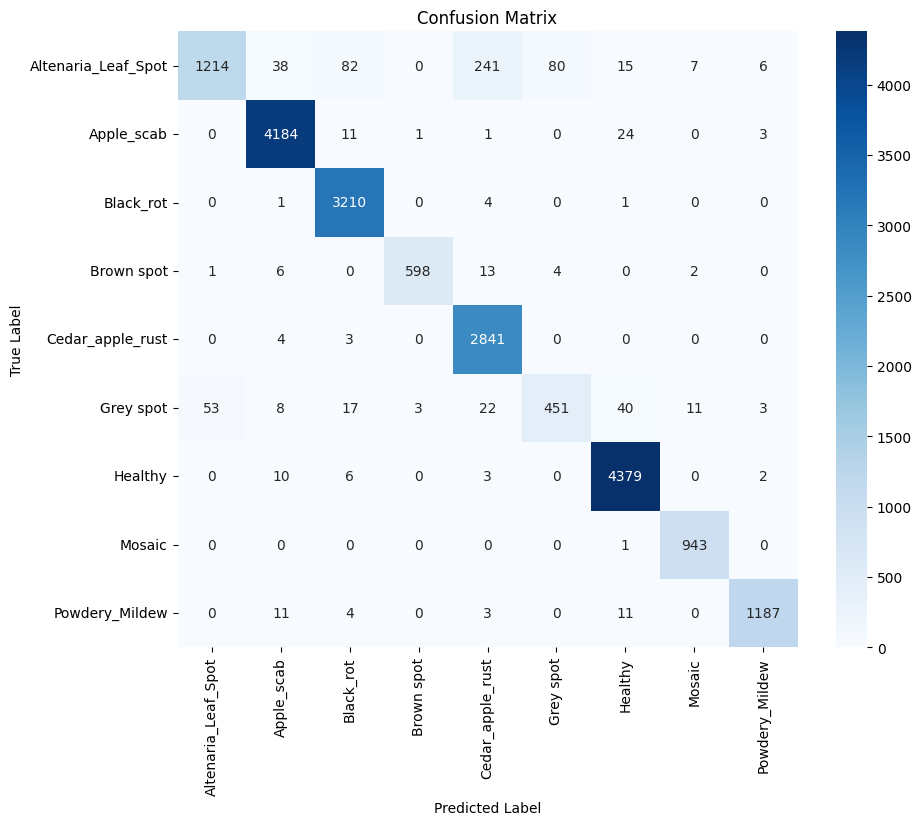

                     precision    recall  f1-score   support

Altenaria_Leaf_Spot       0.96      0.72      0.82      1683
         Apple_scab       0.98      0.99      0.99      4224
          Black_rot       0.96      1.00      0.98      3216
         Brown spot       0.99      0.96      0.98       624
   Cedar_apple_rust       0.91      1.00      0.95      2848
          Grey spot       0.84      0.74      0.79       608
            Healthy       0.98      1.00      0.99      4400
             Mosaic       0.98      1.00      0.99       944
     Powdery_Mildew       0.99      0.98      0.98      1216

           accuracy                           0.96     19763
          macro avg       0.95      0.93      0.94     19763
       weighted avg       0.96      0.96      0.96     19763



In [8]:
# Evaluation Metrics
def plot_history(history, history_fine=None):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    if history_fine:
        acc += history_fine.history['accuracy']
        val_acc += history_fine.history['val_accuracy']
        loss += history_fine.history['loss']
        val_loss += history_fine.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    if history_fine:
        plt.axvline(x=EPOCHS-1, color='green', label='Start Fine Tuning')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    if history_fine:
        plt.axvline(x=EPOCHS-1, color='green', label='Start Fine Tuning')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

if 'history' in locals():
    plot_history(history, history_fine if 'history_fine' in locals() else None)

# Confusion Matrix & Classification Report
print("\nGenerating evaluation report...")
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_labels))

In [8]:
# --- SEVERITY ESTIMATION HEURISTIC ---
def estimate_severity(image_content):
    """
    Estimates disease severity on a scale of 1-5 based on the percentage of diseased area.
    Uses HSV color thresholding to segment the leaf and the spots.
    """
    # Convert bytes to numpy array
    nparr = np.frombuffer(image_content, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    
    if img is None:
        return 0, 0.0

    # Convert to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 1. Segment the Leaf (Green colors)
    # Adjust these thresholds based on your specific lighting/leaf color
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    leaf_mask = cv2.inRange(hsv, lower_green, upper_green)
    
    # 2. Segment Disease Spots (Brown/Yellow/Black/Rust colors)
    # This is tricky as it varies by disease. We'll try to capture non-green parts of the leaf.
    # A simple approach: Leaf Area = Green + Spots. 
    # So we can try to find the whole leaf contour first, then subtract the green part.
    # Or, we can define a range for "brown/yellow" spots.
    
    # Let's try defining a broad range for spots (yellows, browns, dark spots)
    # Yellows
    lower_yellow = np.array([15, 50, 50])
    upper_yellow = np.array([35, 255, 255])
    yellow_mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
    
    # Browns/Rust (often low Hue, or high Hue wrapping around)
    lower_brown = np.array([0, 50, 20])
    upper_brown = np.array([20, 255, 255])
    brown_mask = cv2.inRange(hsv, lower_brown, upper_brown)
    
    # Combine spot masks
    disease_mask = cv2.bitwise_or(yellow_mask, brown_mask)
    
    # Refine: We only care about spots *on* or *near* the leaf.
    # A better heuristic: Total Leaf Area approx = Green Mask + Disease Mask
    # (Assuming background is distinct, e.g., white or black)
    
    green_pixels = cv2.countNonZero(leaf_mask)
    disease_pixels = cv2.countNonZero(disease_mask)
    
    total_leaf_pixels = green_pixels + disease_pixels
    
    if total_leaf_pixels == 0:
        return 0, 0.0
    
    infection_ratio = disease_pixels / total_leaf_pixels
    
    # Map ratio to 1-5 scale
    # These thresholds are heuristic and can be tuned
    if infection_ratio < 0.05:
        severity = 1 # Healthy / Very Mild
    elif infection_ratio < 0.15:
        severity = 2 # Mild
    elif infection_ratio < 0.30:
        severity = 3 # Moderate
    elif infection_ratio < 0.50:
        severity = 4 # Severe
    else:
        severity = 5 # Very Severe
        
    return severity, infection_ratio

In [9]:
# Inference & Visualization Widget
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io
from tensorflow.keras.preprocessing import image as keras_image

def predict_and_visualize(img_content, model, class_indices):
    # 1. Predict Class
    img = Image.open(io.BytesIO(img_content))
    img_resized = img.resize(IMG_SIZE)
    img_array = keras_image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v3.preprocess_input(img_array)

    predictions = model.predict(img_array)
    predicted_class_idx = np.argmax(predictions[0])
    
    labels = {v: k for k, v in class_indices.items()}
    predicted_label = labels[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx]
    
    # 2. Estimate Severity
    severity, ratio = estimate_severity(img_content)
    
    # 3. Visualization
    plt.figure(figsize=(14, 6))

    # Display Image with Results
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Disease: {predicted_label}\nConfidence: {confidence:.2f}\nSeverity: {severity}/5 (Infection: {ratio:.1%})")
    plt.axis('off')

    # Display Probabilities
    plt.subplot(1, 2, 2)
    classes = list(class_indices.keys())
    probs = predictions[0]
    y_pos = np.arange(len(classes))

    plt.barh(y_pos, probs, align='center', color='skyblue')
    plt.yticks(y_pos, classes)
    plt.xlabel('Probability')
    plt.title('Class Probabilities')
    plt.xlim(0, 1)

    plt.tight_layout()
    plt.show()

# File Upload Widget
uploader = widgets.FileUpload(accept='image/*', multiple=False)
output = widgets.Output()

def on_upload_change(change):
    if not change.new:
        return
    uploaded_file = change.new[0] if isinstance(change.new, tuple) else change.new
    if isinstance(uploaded_file, dict) and 'content' not in uploaded_file:
         uploaded_file = list(change.new.values())[0]
    content = uploaded_file['content']
    
    with output:
        clear_output()
        try:
            predict_and_visualize(content, model, class_indices)
        except Exception as e:
            print(f"Error: {e}")

uploader.observe(on_upload_change, names='value')
print("Upload an apple leaf image to analyze:")
display(uploader, output)
print(class_indices)

Upload an apple leaf image to analyze:


FileUpload(value=(), accept='image/*', description='Upload')

Output()

{'Altenaria_Leaf_Spot': 0, 'Apple_scab': 1, 'Black_rot': 2, 'Brown spot': 3, 'Cedar_apple_rust': 4, 'Grey spot': 5, 'Healthy': 6, 'Mosaic': 7, 'Powdery_Mildew': 8}
